# 🚀 Multilingual MT – Baseline LSTM Seq2Seq
**Mô hình:** LSTM Encoder-Decoder (không Attention) – Baseline so sánh

## Hướng dẫn chuẩn bị trước khi chạy
1. Upload thư mục dự án lên Google Drive tại: `MyDrive/Multilingual_MT/`
2. Cấu trúc Drive cần có:
```
MyDrive/Multilingual_MT/
├── data/processed/train.txt
├── data/processed/val.txt
├── data/processed/test.txt
└── tokenizer/tokenizer.json
```
3. Vào **Runtime → Change runtime type → T4 GPU** rồi chạy từng cell.

In [7]:
# ── Cell 1: Kết nối Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Multilingual_MT'
os.makedirs(f'{PROJECT_DIR}/model_assets', exist_ok=True)
print('Drive mounted. Project dir:', PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project dir: /content/drive/MyDrive/Multilingual_MT


In [8]:
# ── Cell 2: Cài đặt thư viện ─────────────────────────────────────────────
!pip install tokenizers -q
import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [9]:
# ── Cell 3: Đường dẫn & Cấu hình ─────────────────────────────────────────
TRAIN_FILE     = f'{PROJECT_DIR}/data/processed/train.txt'
VAL_FILE       = f'{PROJECT_DIR}/data/processed/val.txt'
TEST_FILE      = f'{PROJECT_DIR}/data/processed/test.txt'
TOKENIZER_PATH = f'{PROJECT_DIR}/tokenizer/tokenizer.json'
BEST_MODEL     = f'{PROJECT_DIR}/model_assets/best_baseline_model.pt'
CKPT_DIR       = f'{PROJECT_DIR}/model_assets'

# ── Cấu hình mô hình (ghi vào báo cáo) ───────────────────────────────────
VOCAB_SIZE  = 32_000
EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 2
DROPOUT     = 0.3
PAD_IDX     = 0
EOS_IDX     = 2
MAX_LEN     = 64

# ── Cấu hình huấn luyện ──────────────────────────────────────────────────
NUM_EPOCHS    = 10
BATCH_SIZE    = 128   # Tăng lên 128 vì có GPU
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
GRAD_CLIP     = 1.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [10]:
# ── Cell 4: Data Pipeline ─────────────────────────────────────────────────
from typing import List, Tuple
from tokenizers import Tokenizer
from torch.utils.data import Dataset, DataLoader

def pad_or_trim(ids: List[int], max_len: int = MAX_LEN) -> List[int]:
    if len(ids) < max_len:
        return ids + [PAD_IDX] * (max_len - len(ids))
    return ids[:max_len - 1] + [EOS_IDX]

class MultilingualDataset(Dataset):
    def __init__(self, file_path: str, tokenizer_path: str, max_len: int = MAX_LEN):
        self.max_len = max_len
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.samples: List[Tuple[str, str]] = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t', maxsplit=1)
                if len(parts) == 2 and parts[0] and parts[1]:
                    self.samples.append((parts[0], parts[1]))
        print(f'  Loaded {len(self.samples):,} samples from {os.path.basename(file_path)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        src_text, tgt_text = self.samples[idx]
        src_ids = pad_or_trim(self.tokenizer.encode(src_text).ids)
        tgt_ids = pad_or_trim(self.tokenizer.encode(tgt_text).ids)
        return {
            'src': torch.tensor(src_ids, dtype=torch.long),  # [T]
            'tgt': torch.tensor(tgt_ids, dtype=torch.long),  # [T]
        }

print('Đang nạp dataset...')
train_ds = MultilingualDataset(TRAIN_FILE, TOKENIZER_PATH)
val_ds   = MultilingualDataset(VAL_FILE,   TOKENIZER_PATH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')
# Kiểm tra shape
batch = next(iter(train_loader))
print(f'Batch src: {tuple(batch["src"].shape)} | tgt: {tuple(batch["tgt"].shape)}')

Đang nạp dataset...
  Loaded 255,000 samples from train.txt
  Loaded 30,000 samples from val.txt
Train: 1993 batches | Val: 235 batches
Batch src: (128, 64) | tgt: (128, 64)


In [11]:
# ── Cell 5: Mô hình LSTM Seq2Seq ──────────────────────────────────────────
import torch.nn as nn

class EncoderLSTM(nn.Module):
    """
    src [B,T] → Embedding [B,T,E] → LSTM → hidden [L,B,H], cell [L,B,H]
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)

    def forward(self, src):                       # src: [B, T]
        embedded = self.embedding(src)            # [B, T, E]
        _, (hidden, cell) = self.lstm(embedded)   # [L,B,H], [L,B,H]
        return hidden, cell


class DecoderLSTM(nn.Module):
    """
    tgt[:,:-1] [B,T-1] + (hidden,cell) → LSTM → Linear → logits [B,T-1,V]
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.output_projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, hidden, cell):         # tgt: [B, T-1]
        embedded = self.embedding(tgt)            # [B, T-1, E]
        outputs, _ = self.lstm(embedded, (hidden, cell))  # [B, T-1, H]
        logits = self.output_projection(outputs)  # [B, T-1, V]
        return logits


class LSTMBaseline(nn.Module):
    """
    Seq2Seq LSTM không Attention – Baseline model.
    Teacher Forcing: Decoder nhận tgt[:,:-1], so sánh với tgt[:,1:]
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.encoder = EncoderLSTM(vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx)
        self.decoder = DecoderLSTM(vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx)
        self.config = dict(vocab_size=vocab_size, embed_dim=embed_dim,
                           hidden_dim=hidden_dim, num_layers=num_layers,
                           dropout=dropout, pad_idx=pad_idx)

    def forward(self, src, tgt):                  # src,tgt: [B, T]
        hidden, cell = self.encoder(src)           # [L,B,H]
        logits = self.decoder(tgt[:, :-1], hidden, cell)  # [B, T-1, V]
        return logits


model = LSTMBaseline(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
    dropout=DROPOUT, pad_idx=PAD_IDX,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {total:,}')

# Smoke test
with torch.no_grad():
    dummy_src = torch.randint(1, VOCAB_SIZE, (4, MAX_LEN)).to(DEVICE)
    dummy_tgt = torch.randint(1, VOCAB_SIZE, (4, MAX_LEN)).to(DEVICE)
    out = model(dummy_src, dummy_tgt)
    print(f'Smoke test logits shape: {tuple(out.shape)}')  # (4, 63, 32000)

Tổng tham số: 40,156,416
Smoke test logits shape: (4, 63, 32000)


In [12]:
# ── Cell 6: Loss & Optimizer ──────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # bỏ qua PAD khi tính loss
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=WEIGHT_DECAY,
)
print('Loss: CrossEntropyLoss(ignore_index=0)')
print(f'Optimizer: Adam(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})')

Loss: CrossEntropyLoss(ignore_index=0)
Optimizer: Adam(lr=0.001, weight_decay=1e-05)


In [13]:
# ── Cell 7: Hàm Train / Validate ─────────────────────────────────────────
import time

def run_epoch(model, loader, criterion, optimizer, device, is_training):
    """
    Chạy 1 epoch. Trả về average loss.
    Teacher Forcing:
      input  Decoder: tgt[:, :-1]  → logits [B, T-1, V]
      target         : tgt[:, 1:]  → [B, T-1]
    """
    model.train() if is_training else model.eval()
    total_loss, n_batches = 0.0, 0
    ctx = torch.enable_grad() if is_training else torch.no_grad()

    with ctx:
        for batch in loader:
            src = batch['src'].to(device)   # [B, T]
            tgt = batch['tgt'].to(device)   # [B, T]

            logits = model(src, tgt)        # [B, T-1, V]
            target = tgt[:, 1:]             # [B, T-1]

            B, T1, V = logits.shape
            loss = criterion(
                logits.reshape(B * T1, V),
                target.reshape(B * T1),
            )

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / n_batches if n_batches else float('inf')


def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch':        epoch,
        'model_state':  model.state_dict(),
        'optim_state':  optimizer.state_dict(),
        'val_loss':     val_loss,
        'model_config': model.config,
    }, path)

print('Hàm run_epoch và save_checkpoint đã sẵn sàng.')

Hàm run_epoch và save_checkpoint đã sẵn sàng.


In [14]:
# ── Cell 8: VÒNG LẶP HUẤN LUYỆN (chạy cell này để bắt đầu train) ─────────
best_val_loss = float('inf')
history = []

print('=' * 60)
print(f'  BẮT ĐẦU HUẤN LUYỆN – {NUM_EPOCHS} EPOCH')
print(f'  Device={DEVICE} | batch={BATCH_SIZE} | lr={LEARNING_RATE}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = run_epoch(model, train_loader, criterion,
                           optimizer, DEVICE, is_training=True)
    val_loss   = run_epoch(model, val_loader,   criterion,
                           optimizer, DEVICE, is_training=False)
    elapsed = time.time() - t0

    history.append({'epoch': epoch, 'train': train_loss, 'val': val_loss})
    tag = ' ← BEST' if val_loss < best_val_loss else ''
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] '
          f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | '
          f'{elapsed:.0f}s{tag}')

    # Lưu checkpoint mỗi epoch
    save_checkpoint(model, optimizer, epoch, val_loss,
                    f'{CKPT_DIR}/ckpt_epoch_{epoch:02d}.pt')

    # Lưu best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss, BEST_MODEL)

print('=' * 60)
print(f'HOÀN TẤT! Best Val Loss: {best_val_loss:.4f}')
print(f'Best model: {BEST_MODEL}')

  BẮT ĐẦU HUẤN LUYỆN – 10 EPOCH
  Device=cuda | batch=128 | lr=0.001
Epoch [01/10] Train: 6.0986 | Val: 5.3972 | 849s ← BEST
Epoch [02/10] Train: 5.1454 | Val: 4.9588 | 867s ← BEST
Epoch [03/10] Train: 4.8160 | Val: 4.7437 | 868s ← BEST
Epoch [04/10] Train: 4.6110 | Val: 4.6078 | 867s ← BEST
Epoch [05/10] Train: 4.4648 | Val: 4.4979 | 865s ← BEST
Epoch [06/10] Train: 4.3554 | Val: 4.4259 | 865s ← BEST
Epoch [07/10] Train: 4.2675 | Val: 4.3683 | 864s ← BEST
Epoch [08/10] Train: 4.1938 | Val: 4.3250 | 865s ← BEST
Epoch [09/10] Train: 4.1329 | Val: 4.2793 | 865s ← BEST
Epoch [10/10] Train: 4.0784 | Val: 4.2456 | 867s ← BEST
HOÀN TẤT! Best Val Loss: 4.2456
Best model: /content/drive/MyDrive/Multilingual_MT/model_assets/best_baseline_model.pt


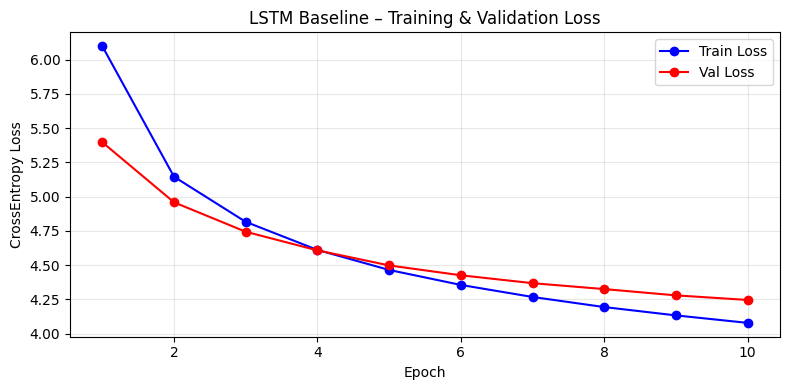

Đã lưu biểu đồ loss vào Drive.


In [15]:
# ── Cell 9: Vẽ đồ thị Loss ───────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs = [h['epoch'] for h in history]
trains = [h['train'] for h in history]
vals   = [h['val']   for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, trains, 'b-o', label='Train Loss')
plt.plot(epochs, vals,   'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.title('LSTM Baseline – Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/loss_curve_baseline.png', dpi=150)
plt.show()
print('Đã lưu biểu đồ loss vào Drive.')